
##Multiple Linear Regression – Toyota Corolla Price Prediction

This notebook performs:

Exploratory Data Analysis (EDA)

Data preprocessing

Multiple Linear Regression (3 models)

Ridge & Lasso regression

Model evaluation (R², RMSE)

Diagnostic plots

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


MARKDOWN CELL 2 – DATA OVERVIEW
Dataset Description

Target Variable: Price

Predictors:

Age

KM

Fuel Type

HP

Automatic

CC

Doors

Gears

Weight

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


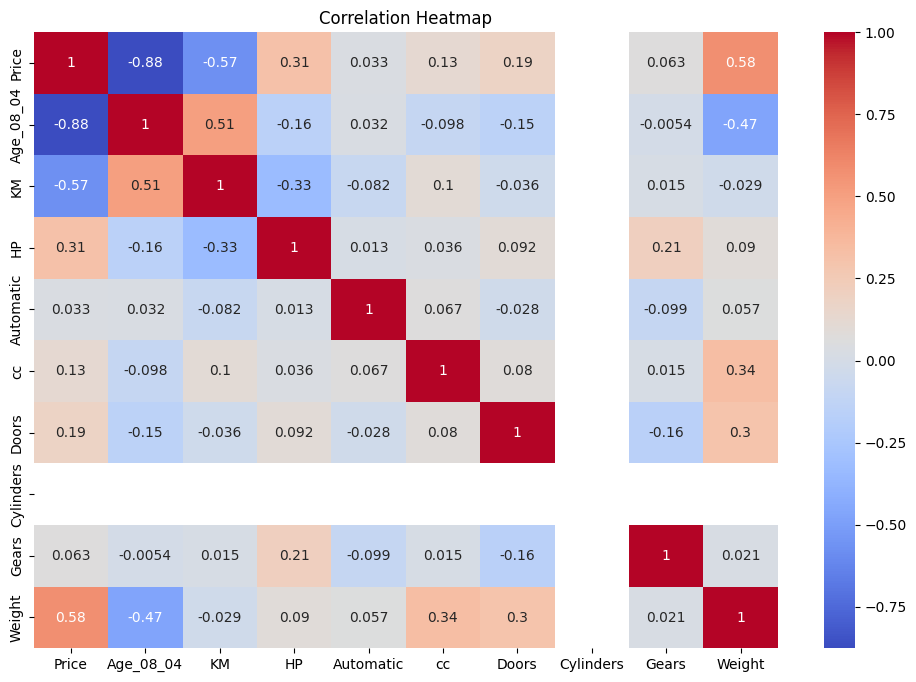

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
df = df.drop(columns=["Cylinders"])

In [9]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [10]:
categorical = ["Fuel_Type"]
numeric = [col for col in X.columns if col not in categorical]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical),
    ("num", StandardScaler(), numeric)
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#MODEL 1 (ALL FEATURES)


In [12]:
model1 = Pipeline([
    ("prep", preprocessor),
    ("lr", LinearRegression())
])

model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

#MODEL 2 (REDUCED FEATURES)

Removed weak predictors: Doors, Automatic

In [13]:
X2 = X.drop(columns=["Doors", "Automatic"])

numeric2 = [col for col in X2.columns if col not in categorical]

preprocessor2 = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical),
    ("num", StandardScaler(), numeric2)
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = Pipeline([
    ("prep", preprocessor2),
    ("lr", LinearRegression())
])

model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)

##MODEL 3 (KEY PREDICTORS)

Using strong predictors: Age, KM, HP, Weight, Fuel_Type

In [14]:
X3 = X[["Age_08_04", "KM", "HP", "Weight", "Fuel_Type"]]

numeric3 = [col for col in X3.columns if col not in categorical]

preprocessor3 = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical),
    ("num", StandardScaler(), numeric3)
])

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

model3 = Pipeline([
    ("prep", preprocessor3),
    ("lr", LinearRegression())
])

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

#RIDGE & LASSO

In [15]:
ridge = Pipeline([
    ("prep", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Pipeline([
    ("prep", preprocessor),
    ("lasso", Lasso(alpha=0.1))
])
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

##MODEL EVALUATION

In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3", "Ridge", "Lasso"],
    "R2": [
        r2_score(y_test, pred1),
        r2_score(y2_test, pred2),
        r2_score(y3_test, pred3),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    "RMSE": [
        rmse(y_test, pred1),
        rmse(y2_test, pred2),
        rmse(y3_test, pred3),
        rmse(y_test, ridge_pred),
        rmse(y_test, lasso_pred)
    ]
})

results

,Model,R2,RMSE
0,Model 1,0.834889,1484.265415
1,Model 2,0.834811,1484.617293
2,Model 3,0.833909,1488.664046
3,Ridge,0.835305,1482.394598
4,Lasso,0.834961,1483.942388


#RESIDUAL PLOT

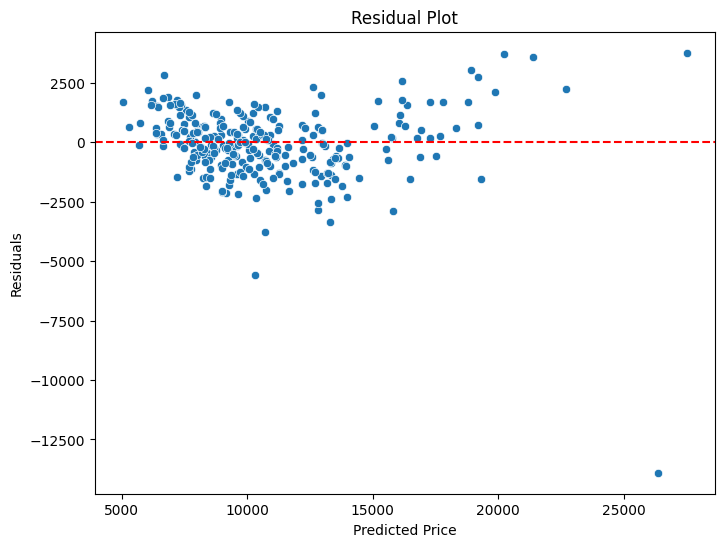

In [17]:
residuals = y_test - pred1

plt.figure(figsize=(8,6))
sns.scatterplot(x=pred1, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#FEATURE IMPORTANCE (COEFFICIENTS)

In [18]:
# Get feature names after encoding
ohe = model1.named_steps["prep"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical)

feature_names = list(encoded_features) + numeric

coefficients = model1.named_steps["lr"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
2,Age_08_04,-2267.294783
1,Fuel_Type_Petrol,1370.808910
9,Weight,1316.818311
3,KM,-611.654412
4,HP,208.349858
8,Gears,109.340417
0,Fuel_Type_Diesel,-68.548757
7,Doors,-57.467804
5,Automatic,34.397130
6,cc,-14.161917


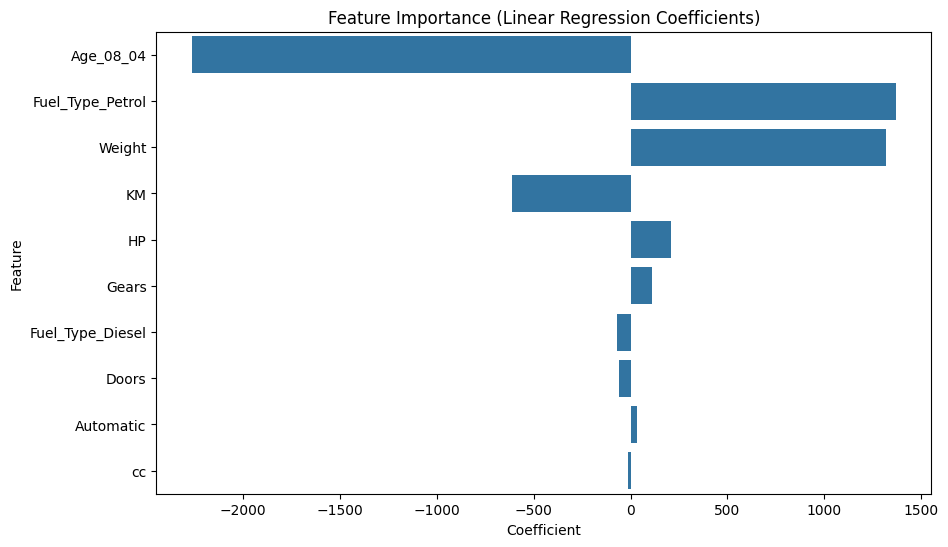

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

##FEATURE IMPORTANCE PLOT


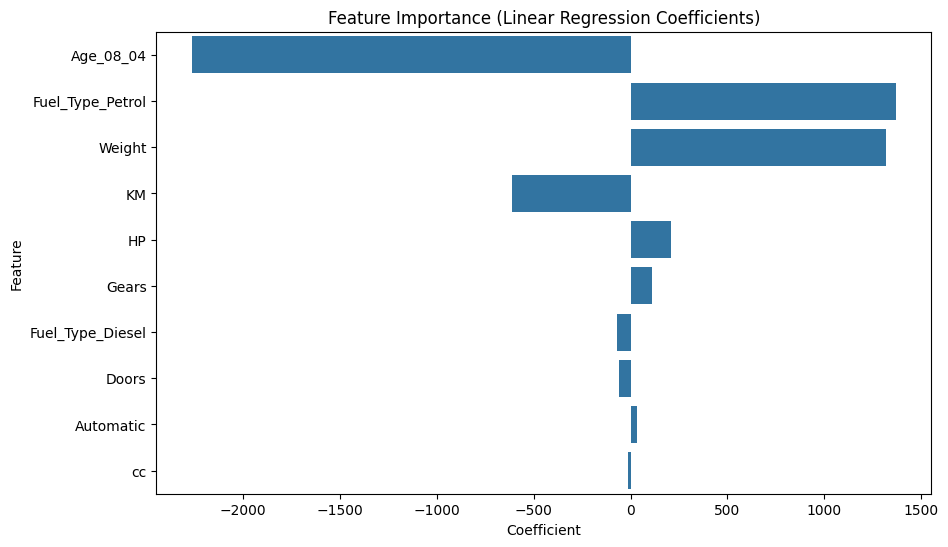

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

##INTERPRETATION
Key Findings

Age and KM have strong negative impact on price

HP and Weight have strong positive impact

Fuel type influences price (Diesel > Petrol)

Ridge regression performed best (lowest RMSE)

Model explains ~83% variance in car price.

##ASSUMPTIONS OF MLR

Linear relationship between predictors and target

No multicollinearity

Homoscedasticity

Normal distribution of residuals

Independence of observations

##INTERVIEW QUESTIONS
What is Normalization?

  Scaling data between 0 and 1

What is Standardization?

  Transforming data to mean = 0, std = 1

How to handle Multicollinearity?

Remove correlated features

Use Ridge/Lasso

Use PCA

Check VIF1